**Insight 2: Job Satisfaction is a Strong Indicator of Performance Rating**<br>
Target variable: PerformanceRating<br>
Model: Logistic Regression<br>
Type: Multiclass classification (ratings from 1 to 4)<br>
Goal: Predict employee performance rating using full dataset

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv("cleaned_employee_data.csv")

In [26]:
X = df.drop(columns=['PerformanceRating'])
y = df['PerformanceRating']

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

In [32]:
log_model = LogisticRegression(max_iter=5000, multi_class='multinomial', solver='lbfgs')
log_model.fit(X_train, y_train)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=5000, multi_class='multinomial')

In [34]:
y_pred = log_model.predict(X_test)

Accuracy: 97.73%

Classification Report:
               precision    recall  f1-score   support

           3       0.98      0.99      0.99       373
           4       0.97      0.88      0.92        68

    accuracy                           0.98       441
   macro avg       0.97      0.94      0.95       441
weighted avg       0.98      0.98      0.98       441



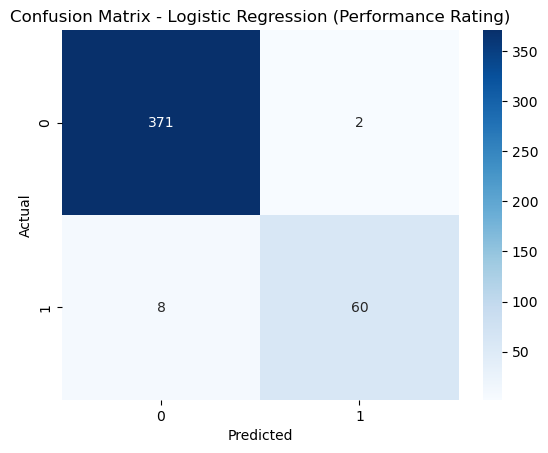

In [36]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=2))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (Performance Rating)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [38]:
# The model is predicting one of 4 classes: 1, 2, 3, or 4, so the classification report will show precision, recall, and F1 for each class separately
# Instead of reporting 4 different F1 scores (one for each class), can take the average of them, giving one single Precision/Recall/F1 value, this makes it fair and consistent when comparing 3 models 
from sklearn.metrics import precision_score, recall_score, f1_score
print("Macro Precision:", precision_score(y_test, y_pred, average='macro')*100)
print("Macro Recall:", recall_score(y_test, y_pred, average='macro')*100)
print("Macro F1 Score:", f1_score(y_test, y_pred, average='macro')*100)

Macro Precision: 97.3316878032173
Macro Recall: 93.84955054407823
Macro F1 Score: 95.48895253682488
